<a href="https://colab.research.google.com/github/rmnmr13/SATAID_example/blob/main/coba_sataid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title 1.1 Clone Repository and Change Directory
!rm -rf sataid-example
!git clone https://github.com/sepriando/sataid-example.git
%cd sataid-example

Cloning into 'sataid-example'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 69 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 24.91 MiB | 11.04 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/sataid-example


In [ ]:
# @title 1.2 Install Required Python Packages
# Install sataid package
#!pip install sataid
!pip install --extra-index-url https://test.pypi.org/simple/ sataid==0.3.3
#install supoorting package
!pip install cartopy rasterio

Looking in indexes: https://pypi.org/simple, https://test.pypi.org/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 53.8 MB/s eta 0:00:00


In [ ]:
# @title 2.1 Load Sataid Data and Display Description

import sataid as sat

# Reading sataid data:
#sataid_file = '/content/sataid-example/data/IRB_20251211.Z0000' #Infrared Band
sataid_file = '/content/sataid-example/data/H09_B13_Indonesia_20240908.Z0000' #Visible band

sat = sat.read_sataid(sataid_file)

# Display description
sat.description()

=== Data Description ===
Time: 2024-09-08 00:00 UTC
Channel: IR
Dimension: 3000x2000
Resolution: 0.019999999552965164
Units: °C
SATAID Version: 1.1 
Coordinate Range:
lat : -19.980000 - 20.000000
lon : 90.000000 - 149.979996

=== Satellite Description ===
Satellite: Himawari-9
Nadir Coordinate: -0.045706, 140.761246
Altitude: 42163.75 km




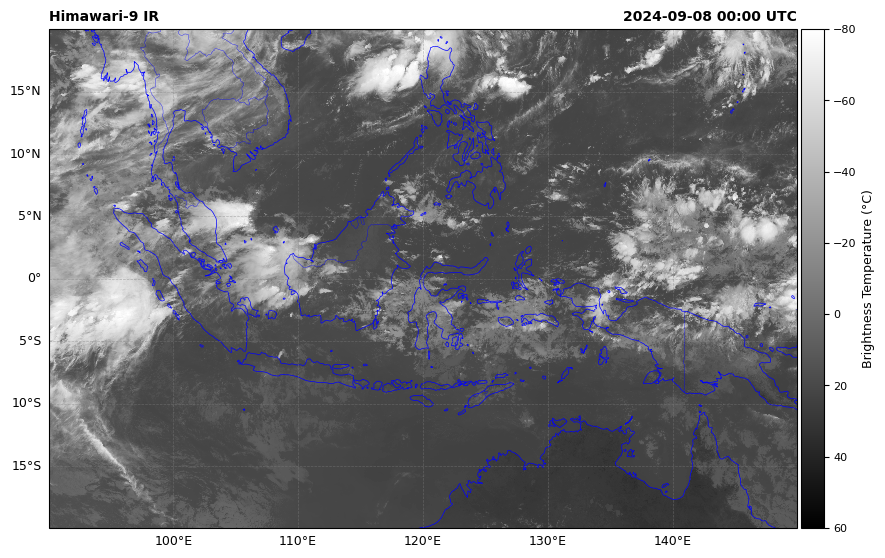

In [ ]:
# @title 3.1 Plot Sataid Data (Default)

sat.plot()

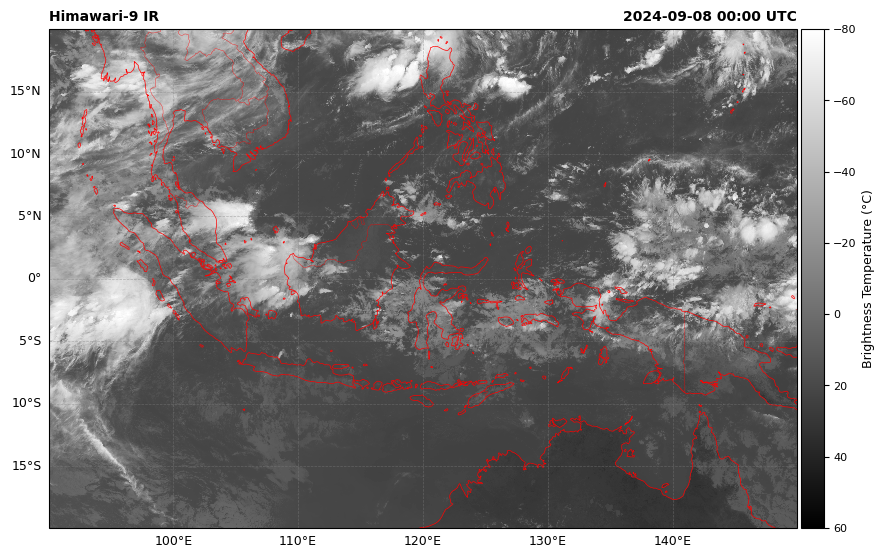

In [ ]:
# @title 3.2 Plot Sataid Data with Cartopy
# Using Cartopy to add geographic context such as coastlines

sat.plot(coastline_color='red')

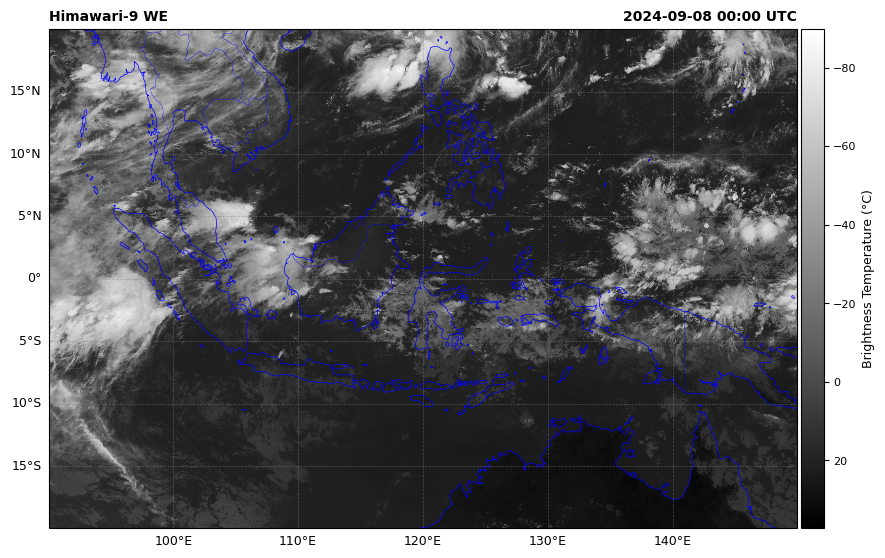

In [ ]:
# @title 3.3 Plot Sataid Data with Cartopy & Custom Colormap

sat.plot(cmap='WE') # You can also try jet, terrain, etc

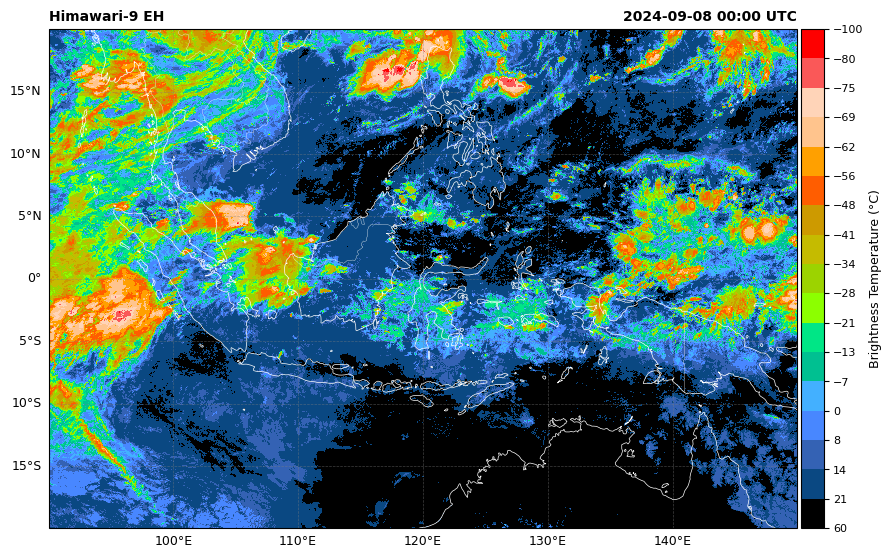

In [ ]:
sat.plot(cmap='EH')

In [ ]:
# @title 4.1 Save Plot (default)

sat.savefig()  #default_name +.png

Saving plot to: H09_B13_Indonesia_20240908.Z0000.png


In [ ]:
# @title 4.2 Save Plot with Custom filename

sat.savefig(cmap='rainbow', output_file='myplot.png')

Saving plot to: myplot.png


In [ ]:
# @title 5.1 Adjust slice for Borneo Area

borneo_box = sat.sel(latitude=slice(7.5, -4.5), longitude=slice(108, 120))
borneo_box.description()

=== Data Description ===
Time: 2024-09-08 00:00 UTC
Channel: IR
Dimension: 600x600
Resolution: 0.019999999552965164
Units: °C
SATAID Version: 1.1 
Coordinate Range:
lat : -4.500000 - 7.480000
lon : 108.019999 - 119.999998

=== Satellite Description ===
Satellite: Himawari-9
Nadir Coordinate: -0.045706, 140.761246
Altitude: 42163.75 km




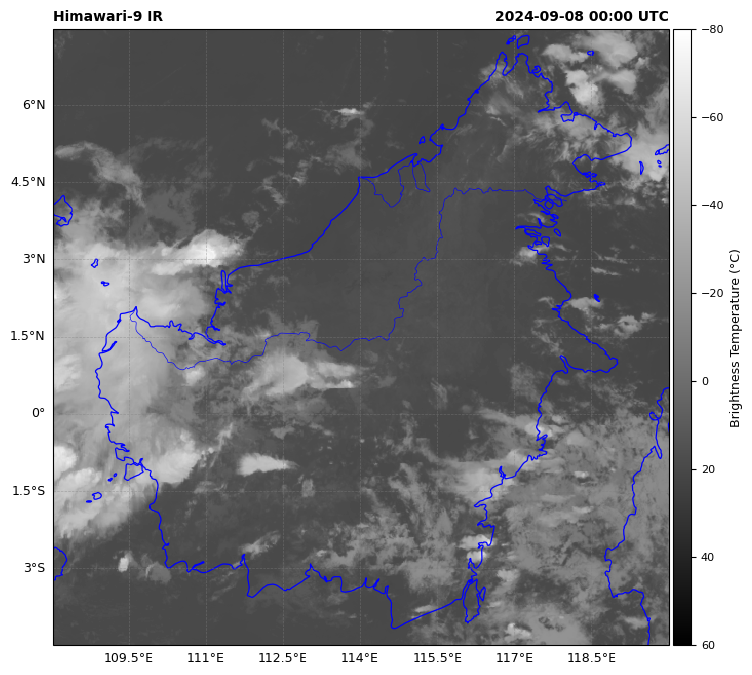

Saving plot to: borneo_box.png


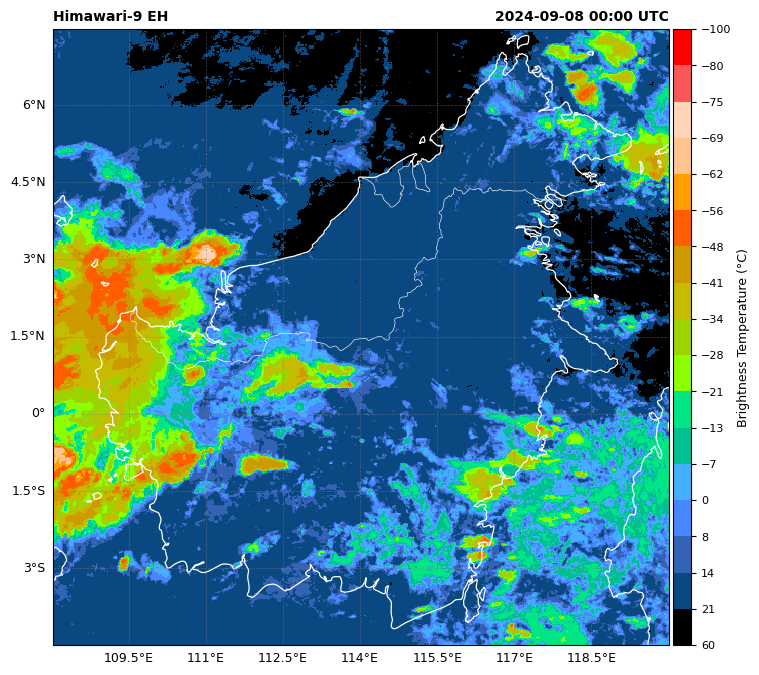

In [ ]:
# @title 5.2 Plot the subsetted area

borneo_box.plot(cartopy=True)

# Save the plot of the subsetted data
borneo_box.savefig(output_file='borneo_box.png',cartopy=True)


In [ ]:
# @title 6.1 Extract Values by Point

# example point
point_lat, point_lon = 1.53, 109.6

# 'nearest' method (default)
val_nearest = sat.sel(latitude=point_lat, longitude=point_lon)
print(f"Value (nearest) at ({point_lat}, {point_lon}) is: {val_nearest:.2f} {sat.units}")

# 'linear' method (requires scipy)
val_linear = sat.sel(latitude=point_lat, longitude=point_lon, method='linear')
print(f"Value (linear) at ({point_lat}, {point_lon}) is: {val_linear:.2f} {sat.units}")

Value (nearest) at (1.53, 109.6) is: -41.37 °C
Value (linear) at (1.53, 109.6) is: -41.34 °C


In [ ]:
# @title 7.1 Convert to netCDF format

borneo_box.to_netcdf() #defaut filename


Error: 'netCDF4' is required for NetCDF export.
Install via: pip install netCDF4


In [ ]:
# @title 7.2 Convert to GeoTiff format

borneo_box.to_geotiff('Satellite.tif') #custom filename

Saving data to GeoTIFF: Satellite.tif


In [ ]:
# @title 7.3 Save to Sataid Format

#borneo_box.to_sataid()

In [ ]:
# @title 8.1 Convert to Xarray DataArray

xr_data = borneo_box.to_xarray()
xr_data

<xarray.DataArray 'IR' (lat: 600, lon: 600)> Size: 3MB
array([[ 20.67278442,  20.67278442,  20.77703247, ...,  -2.40869751,
         -8.80087891,  -2.84226074],
       [ 20.69884644,  20.75097046,  20.77703247, ...,  -3.31165161,
        -12.96900024,  -5.56046143],
       [ 20.72490845,  20.72490845,  20.67278442, ...,  -4.08850708,
         -3.31165161,   0.98345337],
       ...,
       [ 17.49614868,  17.49614868,  19.01717529, ...,  10.01891479,
         13.99526367,  13.7444397 ],
       [ 17.06508789,  19.09661255,  19.09661255, ...,  10.36620483,
         13.21282349,  17.33471069],
       [ 18.21941528,  19.04366455,  19.04366455, ...,  12.33922729,
         15.76088867,  18.08587036]])
Coordinates:
  * lat      (lat) float64 5kB -4.5 -4.48 -4.46 -4.44 ... 7.42 7.44 7.46 7.48
  * lon      (lon) float64 5kB 108.0 108.0 108.1 108.1 ... 120.0 120.0 120.0
Attributes:
    satellite:  Himawari-9
    channel:    IR
    units:      °C
    long_name:  Data from SATAID channel IR

In [ ]:
# @title 8.2 Access data values

xr_data.sel(lat=-10, lon=108, method='nearest')

<xarray.DataArray 'IR' ()> Size: 8B
array(20.67278442)
Coordinates:
    lat      float64 8B -4.5
    lon      float64 8B 108.0
Attributes:
    satellite:  Himawari-9
    channel:    IR
    units:      °C
    long_name:  Data from SATAID channel IR

In [ ]:
# @title 8.3 Calculate the mean value

xr_data.mean()

<xarray.DataArray 'IR' ()> Size: 8B
array(6.23518995)
Attributes:
    satellite:  Himawari-9
    channel:    IR
    units:      °C
    long_name:  Data from SATAID channel IR

In [ ]:
# @title 8.4 Adjust the slice to select a valid range

subset_data = xr_data.sel(lat=slice(-5, 0), lon=slice(110, 120))
subset_data

<xarray.DataArray 'IR' (lat: 225, lon: 500)> Size: 900kB
array([[ 14.96468506,  14.96468506,  15.10241089, ...,  -2.40869751,
         -8.80087891,  -2.84226074],
       [ 15.51448975,  15.51448975,  16.36074219, ...,  -3.31165161,
        -12.96900024,  -5.56046143],
       [ 16.84890137,  17.87182007,  18.24611816, ...,  -4.08850708,
         -3.31165161,   0.98345337],
       ...,
       [-11.13443604, -10.50787964, -14.22949829, ...,   3.50655518,
          3.44432983,  -1.51517334],
       [ -9.77701416,  -7.80097046,  -7.80097046, ...,   2.94503174,
          3.10137329,  -5.76791992],
       [ -8.90875854,  -5.76791992,  -2.5418457 , ...,  -2.60852661,
         -6.84827271,  -9.70432129]])
Coordinates:
  * lat      (lat) float64 2kB -4.5 -4.48 -4.46 -4.44 ... -0.06 -0.04 -0.02
  * lon      (lon) float64 4kB 110.0 110.0 110.1 110.1 ... 120.0 120.0 120.0
Attributes:
    satellite:  Himawari-9
    channel:    IR
    units:      °C
    long_name:  Data from SATAID channel IR

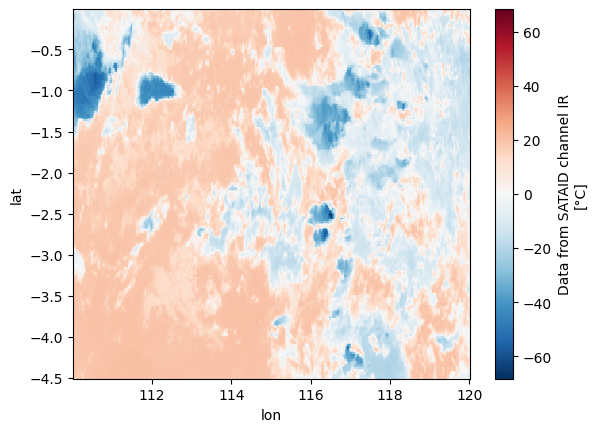

In [ ]:
# @title 8.5 Plot the xarray DataArray

subset_data.plot()

(array([2.17379e+05, 8.33800e+04, 4.35270e+04, 1.01380e+04, 3.39400e+03,
        1.25500e+03, 5.41000e+02, 2.83000e+02, 8.90000e+01, 1.40000e+01]),
 array([0.01117647, 0.10247059, 0.19376471, 0.28505883, 0.37635296,
        0.46764708, 0.5589412 , 0.65023532, 0.74152944, 0.83282356,
        0.92411768]),
 <BarContainer object of 10 artists>)

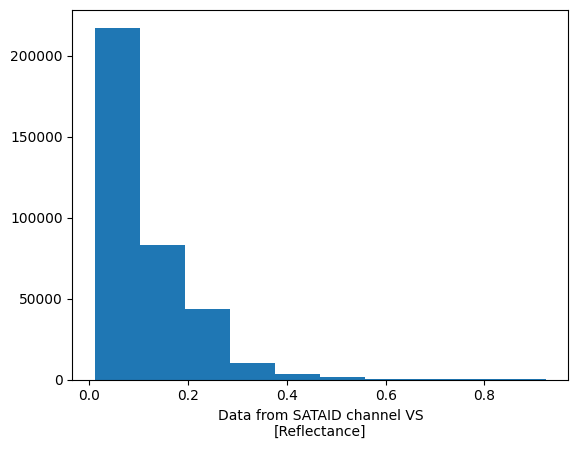

In [ ]:
# @title 8.6 Creating a Histogram of the Data Values

xr_data.plot.hist()